# Clinic Revenue Intelligence

## Objetivo
Transformar dados desorganizados de clínicas em insights claros que aumentam o faturamento e reduzem perdas.

## Problema
A maioria das clínicas trabalha com planilhas desorganizadas, o que gera:
- Perda de faturamento por faltas de pacientes
- Má gestão de agenda
- Falta de visão sobre clientes mais importantes
- Nenhum controle sobre formas de pagamento

## O que este projeto faz
- Limpa e padroniza dados inconsistentes
- Identifica perdas de faturamento
- Analisa comportamento dos clientes
- Mostra os procedimentos mais lucrativos

## Impacto no negócio
Essa análise ajuda clínicas a:
- Recuperar faturamento perdido
- Otimizar agenda
- Identificar clientes de maior valor
- Tomar decisões baseadas em dados

## Tecnologias
- Python (Pandas, NumPy, matplotlib, plotly.express)
- Excel
- Análise e limpeza de dados

---

## English Version (Short)

### Objective
Turn messy clinic data into actionable insights that increase revenue.

### Business Impact
- Reduce revenue loss  
- Improve scheduling  
- Identify high-value clients  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
caminho = r"D:\projetos python\projeto_Clinic Revenue Intelligence"

In [2]:
df_atendimentos = pd.read_excel(
    os.path.join(caminho, "clinic_revenue_intelligence_raw_v2.xlsx")
)

df_pagamentos = pd.read_excel(
    os.path.join(caminho, "clinic_revenue_intelligence_payments.xlsx")
)

In [3]:
df_atendimentos.head()

,data,Id_cliente,paciente,procedimento,valor,status,horario
0,NaN,1055.0,3147,Botox,R$ 2183,Sim,manhã
1,2025-02-02,1063.0,Beatriz Rodrigues,Botox,duzentos,feito,10:00
2,NaN,1033.0,Carlos Pereira,Preenchimento,duzentos,Realizado,manhã
3,2025-04-17,1073.0,Juliana Souza,Botox,duzentos,Sim,08:00
4,2025-03-07,1082.0,NaN,Peeling,duzentos,ok,16:00


In [4]:
df_atendimentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   data          871 non-null    object 
 1   Id_cliente    1144 non-null   float64
 2   paciente      1068 non-null   object 
 3   procedimento  1144 non-null   object 
 4   valor         866 non-null    object 
 5   status        950 non-null    object 
 6   horario       965 non-null    object 
dtypes: float64(1), object(6)
memory usage: 65.8+ KB


In [5]:
df_atendimentos.isnull().sum()

data            329
Id_cliente       56
paciente        132
procedimento     56
valor           334
status          250
horario         235
dtype: int64

### Insight inicial: Não é possível confiar nos dados — ainda.

A base apresenta inconsistências que impedem uma análise precisa do faturamento e da operação da clínica.

Antes de qualquer insight de negócio, será necessário tratar e padronizar os dados.

Esse será o primeiro passo para transformar dados brutos em decisões estratégicas.

In [6]:
# Indentificaremos os atendimentos duplicados:
df_atendimentos.duplicated().sum()

np.int64(55)

Foram identificadas 55 linhas completamente duplicadas na base de dados.
### Tradução para negócio
Isso pode significar:

- erro de registro manual
- duplicidade de agendamento
- ou pior: faturamento inflado artificialmente

In [7]:
df_atendimentos["valor"].unique()

array(['R$ 2183', 'duzentos', 204, 'R$ 2866', nan, 1184, 1764, 'R$ 2871',
       253, 1835, 192, 345, 'R$ 289', 115, 651, 430, 119, 'R$ 2476',
       'R$ 234', 556, 108, 'R$ 2085', 1383, 'R$ 274', 1210, 'R$ 220',
       'R$ 261', 1103, 'R$ 1394', 2213, 197, 'R$ 919', 2908, 'R$ 132',
       'R$ 1830', 'R$ 389', 'R$ 255', 1781, 'R$ 431', 131, 'R$ 2500', 225,
       'R$ 260', 'R$ 1607', 311, 2407, 149, 339, 2377, 'R$ 178',
       'R$ 1188', 'R$ 1542', 132, 'R$ 213', 'R$ 2241', 1034, 102,
       'R$ 750', 165, 1717, 193, 'R$ 744', 191, 'R$ 2431', 'R$ 395', 592,
       1048, 'R$ 1722', 2428, 681, 'R$ 267', 164, 'R$ 378', 278,
       'R$ 1144', 346, 'R$ 410', 236, 2299, 1896, 'R$ 1799', 293,
       'R$ 239', 'R$ 202', 1510, 2360, 'R$ 120', 1081, 'R$ 181', 213,
       'R$ 123', 'R$ 258', 2338, 296, 'R$ 2046', 838, 348, 297, 180,
       'R$ 305', 'R$ 1301', 2100, 'R$ 1219', 298, 'R$ 2498', 340,
       'R$ 851', 'R$ 163', 'R$ 324', 252, 'R$ 2641', 'R$ 846', 'R$ 185',
       1770, 'R$ 308', 222,

In [8]:
# Para descobrirmos o tamanho da tabela de atendimentos:
df_atendimentos.shape

(1200, 7)

In [9]:
# Para descobrirmos o tamanho da tabela de pagamentos:
df_pagamentos.shape

(1200, 3)

In [10]:
df_atendimentos[df_atendimentos.duplicated()]

,data,Id_cliente,paciente,procedimento,valor,status,horario
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


serão removidas essas 55 linhas completamente vazias:



In [11]:
df_atendimentos = df_atendimentos.dropna(how="all")

In [12]:
df_atendimentos.shape

(1144, 7)

In [13]:
df_pagamentos[df_pagamentos.isnull().all(axis=1)]

,id_atendimento,Id_cliente,forma_pagamento


In [14]:
df_atendimentos["valor"].head(10)

0     R$ 2183
1    duzentos
2    duzentos
3    duzentos
4    duzentos
5         204
6     R$ 2866
7         NaN
8         NaN
9    duzentos
Name: valor, dtype: object

In [15]:
df_atendimentos["valor"].tail(10)

1190        2405
1191      R$ 166
1192    duzentos
1193    duzentos
1194         271
1195         NaN
1196         278
1197    duzentos
1198         353
1199     R$ 2366
Name: valor, dtype: object

In [16]:
df_atendimentos["data"] = pd.to_datetime(
    df_atendimentos["data"],
    errors="coerce"
)

In [17]:
df_atendimentos["data"].dtype

dtype('<M8[ns]')

In [18]:
display(df_atendimentos["data"].head())

0          NaT
1   2025-02-02
2          NaT
3   2025-04-17
4   2025-03-07
Name: data, dtype: datetime64[ns]

In [19]:
df_atendimentos["data"].isnull().sum()

np.int64(850)

## Data Quality Issue – Coluna "data"

### Diagnóstico
- 850 registros com datas inválidas (~75% da base)
- Alto risco de perda de dados relevantes caso removidos

### Decisão
A coluna foi mantida para preservar o volume de dados e evitar distorções na análise.

### Insight de Negócio
A ausência de datas confiáveis compromete análises temporais, como:
- faturamento por período
- sazonalidade de atendimentos
- otimização de agenda

### Recomendação
Reforçar o preenchimento correto dos dados no momento da admissão/anamnese do paciente, garantindo maior qualidade das análises futuras.

In [20]:
df_atendimentos["procedimento"].unique()

array(['Botox', 'Preenchimento', 'Peeling', 'Limpeza de Pele',
       'Reposição Hormonal', 'Consulta'], dtype=object)

In [21]:
df_atendimentos['valor'].apply(type).value_counts()

valor
<class 'str'>      567
<class 'int'>      299
<class 'float'>    278
Name: count, dtype: int64

In [22]:
df_atendimentos['valor'].head(10)

0     R$ 2183
1    duzentos
2    duzentos
3    duzentos
4    duzentos
5         204
6     R$ 2866
7         NaN
8         NaN
9    duzentos
Name: valor, dtype: object

In [23]:
df_atendimentos['valor_limpo'] = df_atendimentos['valor'].str.replace('R$', '', regex=False)

In [24]:
df_atendimentos[['valor', 'valor_limpo']].head(10)

,valor,valor_limpo
0,R$ 2183,2183
1,duzentos,duzentos
2,duzentos,duzentos
3,duzentos,duzentos
4,duzentos,duzentos
5,204,NaN
6,R$ 2866,2866
7,NaN,NaN
8,NaN,NaN
9,duzentos,duzentos


In [25]:
df_atendimentos['valor_limpo'] = df_atendimentos['valor_limpo'].replace('duzentos', '200')

In [26]:
df_atendimentos[['valor', 'valor_limpo']].head(10)

,valor,valor_limpo
0,R$ 2183,2183
1,duzentos,200
2,duzentos,200
3,duzentos,200
4,duzentos,200
5,204,NaN
6,R$ 2866,2866
7,NaN,NaN
8,NaN,NaN
9,duzentos,200


### Tratamento da coluna `valor`

Foi realizada uma padronização inicial dos dados da coluna `valor`, com os seguintes ajustes:

- Remoção do prefixo "R$" dos valores monetários  
- Substituição de valores escritos por extenso ("duzentos") por seu equivalente numérico (200)  

Essa etapa tem como objetivo preparar os dados para conversão futura em formato numérico, mantendo a coluna original intacta e criando uma versão tratada (`valor_limpo`).

In [27]:
df_atendimentos['valor'].unique()


array(['R$ 2183', 'duzentos', 204, 'R$ 2866', nan, 1184, 1764, 'R$ 2871',
       253, 1835, 192, 345, 'R$ 289', 115, 651, 430, 119, 'R$ 2476',
       'R$ 234', 556, 108, 'R$ 2085', 1383, 'R$ 274', 1210, 'R$ 220',
       'R$ 261', 1103, 'R$ 1394', 2213, 197, 'R$ 919', 2908, 'R$ 132',
       'R$ 1830', 'R$ 389', 'R$ 255', 1781, 'R$ 431', 131, 'R$ 2500', 225,
       'R$ 260', 'R$ 1607', 311, 2407, 149, 339, 2377, 'R$ 178',
       'R$ 1188', 'R$ 1542', 132, 'R$ 213', 'R$ 2241', 1034, 102,
       'R$ 750', 165, 1717, 193, 'R$ 744', 191, 'R$ 2431', 'R$ 395', 592,
       1048, 'R$ 1722', 2428, 681, 'R$ 267', 164, 'R$ 378', 278,
       'R$ 1144', 346, 'R$ 410', 236, 2299, 1896, 'R$ 1799', 293,
       'R$ 239', 'R$ 202', 1510, 2360, 'R$ 120', 1081, 'R$ 181', 213,
       'R$ 123', 'R$ 258', 2338, 296, 'R$ 2046', 838, 348, 297, 180,
       'R$ 305', 'R$ 1301', 2100, 'R$ 1219', 298, 'R$ 2498', 340,
       'R$ 851', 'R$ 163', 'R$ 324', 252, 'R$ 2641', 'R$ 846', 'R$ 185',
       1770, 'R$ 308', 222,

In [28]:
df_atendimentos['valor'] = (
    df_atendimentos['valor']
    .astype(str)
    .str.replace('R\\$', '', regex=True)
    .str.strip()
)

In [29]:
df_atendimentos['valor'].unique()


array(['2183', 'duzentos', '204', '2866', 'nan', '1184', '1764', '2871',
       '253', '1835', '192', '345', '289', '115', '651', '430', '119',
       '2476', '234', '556', '108', '2085', '1383', '274', '1210', '220',
       '261', '1103', '1394', '2213', '197', '919', '2908', '132', '1830',
       '389', '255', '1781', '431', '131', '2500', '225', '260', '1607',
       '311', '2407', '149', '339', '2377', '178', '1188', '1542', '213',
       '2241', '1034', '102', '750', '165', '1717', '193', '744', '191',
       '2431', '395', '592', '1048', '1722', '2428', '681', '267', '164',
       '378', '278', '1144', '346', '410', '236', '2299', '1896', '1799',
       '293', '239', '202', '1510', '2360', '120', '1081', '181', '123',
       '258', '2338', '296', '2046', '838', '348', '297', '180', '305',
       '1301', '2100', '1219', '298', '2498', '340', '851', '163', '324',
       '252', '2641', '846', '185', '1770', '308', '222', '134', '624',
       '228', '100', '107', '2573', '1278', '300

In [30]:
df_atendimentos[
    ~df_atendimentos['valor'].astype(str).str.replace('R$', '', regex=False).str.strip().str.replace('.', '', regex=False).str.isnumeric()
]['valor'].unique()

array(['duzentos', 'nan'], dtype=object)

In [31]:
df_atendimentos['valor'] = df_atendimentos['valor'].replace({
    'duzentos': 200,
    'nan': None
})

In [32]:
df_atendimentos['valor'] = pd.to_numeric(df_atendimentos['valor'], errors='coerce')

In [33]:
df_atendimentos['valor'].unique()

array([2183.,  200.,  204., 2866.,   nan, 1184., 1764., 2871.,  253.,
       1835.,  192.,  345.,  289.,  115.,  651.,  430.,  119., 2476.,
        234.,  556.,  108., 2085., 1383.,  274., 1210.,  220.,  261.,
       1103., 1394., 2213.,  197.,  919., 2908.,  132., 1830.,  389.,
        255., 1781.,  431.,  131., 2500.,  225.,  260., 1607.,  311.,
       2407.,  149.,  339., 2377.,  178., 1188., 1542.,  213., 2241.,
       1034.,  102.,  750.,  165., 1717.,  193.,  744.,  191., 2431.,
        395.,  592., 1048., 1722., 2428.,  681.,  267.,  164.,  378.,
        278., 1144.,  346.,  410.,  236., 2299., 1896., 1799.,  293.,
        239.,  202., 1510., 2360.,  120., 1081.,  181.,  123.,  258.,
       2338.,  296., 2046.,  838.,  348.,  297.,  180.,  305., 1301.,
       2100., 1219.,  298., 2498.,  340.,  851.,  163.,  324.,  252.,
       2641.,  846.,  185., 1770.,  308.,  222.,  134.,  624.,  228.,
        100.,  107., 2573., 1278.,  300., 1272., 2198.,  974.,  157.,
        829., 2683.,

In [34]:
df_atendimentos['valor'].isna().sum()

np.int64(278)

In [35]:
df_atendimentos.columns

Index(['data', 'Id_cliente', 'paciente', 'procedimento', 'valor', 'status',
       'horario', 'valor_limpo'],
      dtype='object')

In [36]:
df_atendimentos[df_atendimentos['valor'].isna()]['procedimento'].value_counts()

procedimento
Limpeza de Pele       67
Consulta              63
Preenchimento         52
Botox                 41
Reposição Hormonal    29
Peeling               26
Name: count, dtype: int64

## Tratamento de valores ausentes na coluna `valor`

Durante a etapa de limpeza dos dados, identificamos aproximadamente 278 registros com valores ausentes na coluna de faturamento (`valor`), representando cerca de 24% da base.

Ao analisar a distribuição desses valores ausentes, observamos que eles estão concentrados em diferentes tipos de procedimentos, o que indica que não se trata de um erro aleatório, mas sim de um padrão relacionado ao processo de registro dos dados.

Diante disso, optamos por uma abordagem de imputação por mediana **segmentada por procedimento**.

A escolha da mediana em vez da média se deve ao fato de que a mediana é menos sensível a valores extremos (outliers), tornando-a uma medida mais robusta para representar o comportamento típico de faturamento em cada categoria de serviço.

Essa abordagem preserva o volume de dados da base e reduz distorções nas análises de receita e ticket médio por procedimento.

In [37]:
df_atendimentos['valor'] = df_atendimentos['valor'].fillna(
    df_atendimentos.groupby('procedimento')['valor'].transform('median')
)

In [38]:
df_atendimentos.isna().sum()

data            850
Id_cliente        0
paciente         76
procedimento      0
valor             0
status          194
horario         179
valor_limpo     577
dtype: int64

In [39]:
df_atendimentos['valor_limpo'].head(20)

0      2183
1       200
2       200
3       200
4       200
5       NaN
6      2866
7       NaN
8       NaN
9       200
10      NaN
11      NaN
13      NaN
14      NaN
16     2871
17      NaN
18      NaN
19      NaN
20      200
21      NaN
Name: valor_limpo, dtype: object

In [40]:
df_atendimentos['valor'].head(20)

0     2183.0
1      200.0
2      200.0
3      200.0
4      200.0
5      204.0
6     2866.0
7      200.0
8      345.0
9      200.0
10    1184.0
11    1764.0
13    1533.0
14    1695.0
16    2871.0
17     253.0
18    1144.0
19    1835.0
20     200.0
21     192.0
Name: valor, dtype: float64

In [41]:
df_atendimentos['valor'].apply(lambda x: not isinstance(x, (int, float))).sum()

np.int64(0)

### Só então começaremos a anlisar as `perguntas de negócios`

In [42]:
# receita total do período (jan–abr 2025):
df_atendimentos['valor'].sum()

np.float64(845808.0)

In [43]:
df_atendimentos.groupby('procedimento')['valor'].sum().sort_values(ascending=False).head(5)

procedimento
Preenchimento         260723.0
Botox                 257958.0
Reposição Hormonal    160794.0
Limpeza de Pele        58515.0
Consulta               57871.0
Name: valor, dtype: float64

Top 5 por faturamento (O que isso vai nos mostrar?):
- quais procedimentos mais geram receita
- concentração de faturamento (se poucos dominam tudo)
- base para decisões estratégicas da clínica

In [44]:
df_atendimentos['procedimento'].value_counts()

procedimento
Limpeza de Pele       294
Consulta              228
Botox                 221
Preenchimento         171
Peeling               119
Reposição Hormonal    111
Name: count, dtype: int64

In [45]:
df_atendimentos.groupby('procedimento')['valor'].mean().sort_values(ascending=False)

procedimento
Preenchimento         1524.695906
Reposição Hormonal    1448.594595
Botox                 1167.230769
Peeling                419.722689
Consulta               253.820175
Limpeza de Pele        199.030612
Name: valor, dtype: float64

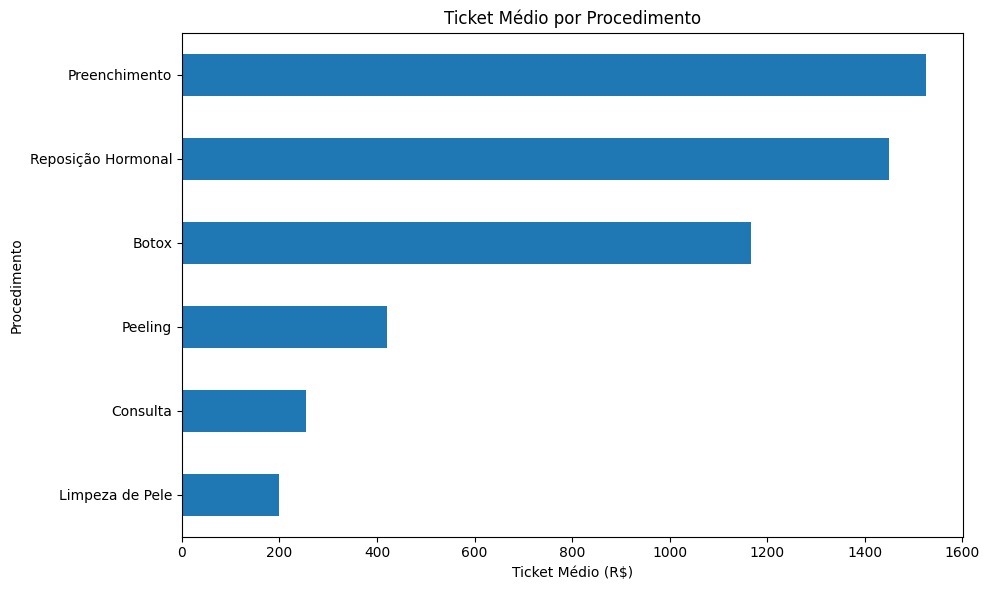

In [46]:
import matplotlib.pyplot as plt

ticket_medio = df_atendimentos.groupby('procedimento')['valor'].mean().sort_values()

plt.figure(figsize=(10,6))
ticket_medio.plot(kind='barh')

plt.title('Ticket Médio por Procedimento')
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Procedimento')

plt.tight_layout()

plt.savefig(r'D:\projetos python\projeto_Clinic Revenue Intelligence\graficos\ticket_medio_por_procedimento.png', dpi=300)

plt.show()

## Relação entre volume e ticket médio: o efeito de alto valor com volume moderado

A análise do ticket médio por procedimento revela um padrão importante no modelo de receita da clínica.

Embora procedimentos como Preenchimento e Reposição Hormonal não apresentem o maior volume de atendimentos, ambos se destacam pelo alto ticket médio, ficando próximos ou até acima de serviços mais frequentes.

Isso evidencia um fenômeno comum em negócios de saúde e estética: serviços com menor volume podem gerar receita significativamente alta devido ao seu maior valor agregado.

Em especial, a Reposição Hormonal se destaca como um serviço de alto valor clínico e financeiro, indicando um modelo baseado em acompanhamento contínuo e maior complexidade terapêutica.

Esse comportamento reforça a existência de dois perfis de receita na clínica:
- Serviços de alto volume e menor ticket (ex: consultas e limpeza de pele)
- Serviços de menor volume e alto ticket (ex: preenchimento, botox e reposição hormonal)

Essa combinação sugere um modelo híbrido de geração de receita, equilibrando escala e valor agregado.

In [47]:
resumo = df_atendimentos.groupby('procedimento').agg(
    ticket_medio=('valor', 'mean'),
    volume=('valor', 'count'),
    receita_total=('valor', 'sum')
).reset_index()

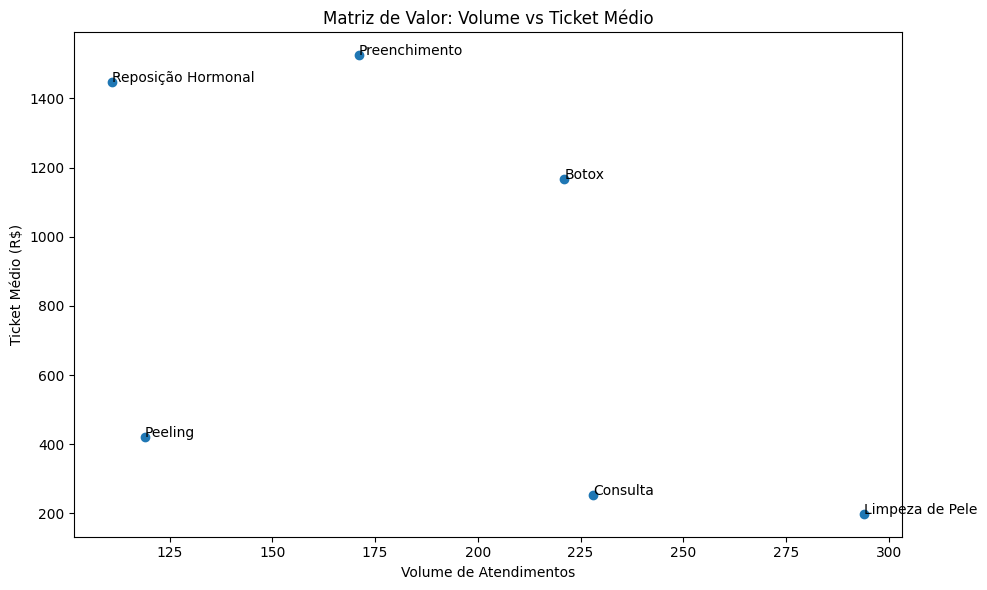

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    resumo['volume'],
    resumo['ticket_medio']
)

for i in range(resumo.shape[0]):
    plt.text(
        resumo['volume'][i],
        resumo['ticket_medio'][i],
        resumo['procedimento'][i]
    )

plt.title('Matriz de Valor: Volume vs Ticket Médio')
plt.xlabel('Volume de Atendimentos')
plt.ylabel('Ticket Médio (R$)')

plt.tight_layout()

plt.savefig(r'D:\projetos python\projeto_Clinic Revenue Intelligence\graficos\matriz_volume_ticket.png', dpi=300)

plt.show()

vamos criar um criar um “Índice de Valor do Procedimento” com o objetivo de combinar volume, ticket médio e receita total.


In [49]:
resumo['volume_norm'] = resumo['volume'] / resumo['volume'].max()
resumo['ticket_norm'] = resumo['ticket_medio'] / resumo['ticket_medio'].max()
resumo['receita_norm'] = resumo['receita_total'] / resumo['receita_total'].max()

In [50]:
resumo['indice_valor'] = (
    resumo['volume_norm'] +
    resumo['ticket_norm'] +
    resumo['receita_norm']
) / 3

In [51]:
resumo.sort_values(by='indice_valor', ascending=False)

,procedimento,ticket_medio,volume,receita_total,volume_norm,ticket_norm,receita_norm,indice_valor
4,Preenchimento,1524.695906,171,260723.0,0.581633,1.000000,1.000000,0.860544
0,Botox,1167.230769,221,257958.0,0.751701,0.765550,0.989395,0.835548
5,Reposição Hormonal,1448.594595,111,160794.0,0.377551,0.950088,0.616723,0.648121
2,Limpeza de Pele,199.030612,294,58515.0,1.000000,0.130538,0.224434,0.451657
1,Consulta,253.820175,228,57871.0,0.775510,0.166473,0.221964,0.387982
3,Peeling,419.722689,119,49947.0,0.404762,0.275283,0.191571,0.290539


In [52]:
resumo['indice_valor'] = (
    resumo['volume_norm'] * 0.3 +
    resumo['ticket_norm'] * 0.4 +
    resumo['receita_norm'] * 0.3
)

In [53]:
import plotly.express as px

fig = px.scatter(
    resumo,
    x='volume',
    y='ticket_medio',
    size='receita_total',
    color='indice_valor',
    hover_name='procedimento',
    size_max=60,
    title='Matriz Interativa: Volume vs Ticket Médio (Índice de Valor)'
)

fig.write_html(r'D:\projetos python\projeto_Clinic Revenue Intelligence\graficos\matriz_interativa.html')

fig.show()

vamos agora buscar as diferentes modalidades de pagamentos:
- ranking das formas de pagamento
- qual é a mais usada (cartão, pix, dinheiro, etc.)
- distribuição de comportamento do cliente

In [54]:
df_pagamentos['forma_pagamento'].value_counts()

forma_pagamento
Pix                  516
Cartão de Crédito    313
Cartão de Débito     186
Dinheiro             185
Name: count, dtype: int64

In [55]:
df_merged = df_atendimentos.merge(df_pagamentos, on='Id_cliente', how='inner')

In [56]:
df_merged.groupby('forma_pagamento')['valor'].sum().sort_values(ascending=False)

forma_pagamento
Pix                  2828430.0
Cartão de Crédito    1790462.0
Dinheiro             1046943.0
Cartão de Débito      994007.0
Name: valor, dtype: float64

Vamos agora descobrir clientes que voltaram (recorrência) e o top 5 clientes que mais gastaram.
Para a clínica isso é importante? Claro!
- fidelização
- retenção
- ações de marketing (voucher)

In [57]:
df_atendimentos['Id_cliente'].value_counts()

Id_cliente
1076.0    15
1020.0    14
1043.0    14
1062.0    14
1147.0    14
          ..
1105.0     3
1037.0     3
1035.0     3
1139.0     2
1074.0     2
Name: count, Length: 151, dtype: int64

In [58]:
#Top 5 clientes que mais gastaram:
# Clientes valiosos:
df_atendimentos.groupby('Id_cliente')['valor'].sum().sort_values(ascending=False).head(5)

Id_cliente
1020.0    13750.0
1028.0    13169.0
1022.0    12357.0
1147.0    11992.0
1102.0    11700.0
Name: valor, dtype: float64

## Frequência vs Valor: nem sempre quem mais vem é quem mais gasta

Durante a análise dos dados, identificamos um ponto importante no comportamento dos clientes da clínica.

Inicialmente, ao observar a frequência de atendimentos, o cliente de ID 1076 se destacou como o mais recorrente, com o maior número de visitas ao longo do período analisado.

No entanto, ao analisar o faturamento total por cliente, observamos que esse mesmo cliente não aparece entre os cinco que mais geraram receita.

Esse resultado evidencia um fenômeno relevante:

> Clientes com alta frequência de atendimentos não necessariamente são os que mais geram receita para a clínica.

Isso pode ocorrer por diversos fatores, como:
- realização de procedimentos de menor valor
- uso recorrente de serviços básicos
- menor ticket médio por atendimento

Por outro lado, clientes com menor frequência podem apresentar maior impacto financeiro, devido à realização de procedimentos de alto valor agregado.

Esse insight reforça a importância de analisar simultaneamente:
- frequência de visitas (engajamento)
- valor total gasto (impacto financeiro)

A combinação dessas duas dimensões permite uma segmentação mais estratégica da base de clientes, possibilitando ações mais eficazes de fidelização, retenção e aumento de receita.

In [59]:
df_atendimentos.groupby('procedimento')['valor'].mean().sort_values(ascending=False)

procedimento
Preenchimento         1524.695906
Reposição Hormonal    1448.594595
Botox                 1167.230769
Peeling                419.722689
Consulta               253.820175
Limpeza de Pele        199.030612
Name: valor, dtype: float64

- O que o código acima responde:

quais procedimentos são mais rentáveis por atendimento

quem é premium vs básico


- base para decisões como:

foco comercial

precificação

priorização de agenda

<Figure size 1000x600 with 0 Axes>

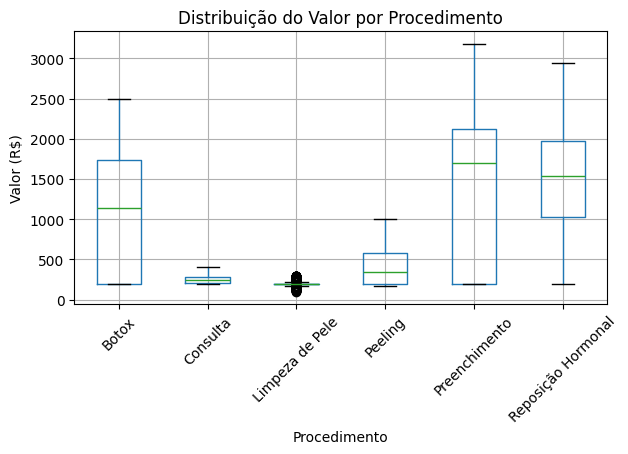

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df_atendimentos.boxplot(column='valor', by='procedimento')

plt.title('Distribuição do Valor por Procedimento')
plt.suptitle('')  

plt.xlabel('Procedimento')
plt.ylabel('Valor (R$)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(r'D:\projetos python\projeto_Clinic Revenue Intelligence\graficos\boxplot_valor_por_procedimento.png', dpi=300)

plt.show()

Não basta saber quanto um procedimento gera em média — é essencial entender a variabilidade desse faturamento.

In [61]:
df_atendimentos['status'].value_counts()

status
ok           199
Realizado    198
Sim          197
cancelado    183
feito        173
Name: count, dtype: int64

### Observe o "calo" de muitas empresas: `perda de faturamento` -> pode ter várias causas — precisamos identificar corretamente

Primeiro: o que pode ser “perda”?


- atendimentos sem valor 
- status que indicam cancelamento / não pagamento
- inconsistência entre atendimento e pagamento
- valores muito baixos (possível erro ou desconto excessivo)

Obs.: nesta base foi encontrado o status cancelado. Isso é perda direta de receita potencial

In [62]:
df_atendimentos[df_atendimentos['status'] == 'cancelado']['valor'].sum()

np.float64(146594.0)

In [63]:
#analisando a taxa percentual de cancelamentos:

(df_atendimentos['status'] == 'cancelado').mean() * 100

np.float64(15.996503496503497)

## Impacto financeiro dos cancelamentos

A análise dos atendimentos cancelados revelou uma perda potencial de faturamento de aproximadamente R$ 146.594.

Esse valor é altamente relevante, pois se aproxima do faturamento total gerado por procedimentos importantes da clínica, como a Reposição Hormonal.

Esse resultado evidencia que os cancelamentos não representam apenas uma questão operacional, mas também um impacto financeiro significativo, equivalente a uma linha relevante de receita do negócio.

O insight reforça a importância de estratégias para redução de cancelamentos, como confirmação de agenda, políticas de remarcação e melhoria na gestão do relacionamento com pacientes.

In [64]:
top_clientes = df_atendimentos['Id_cliente'].value_counts().head(5).index

df_atendimentos[df_atendimentos['Id_cliente'].isin(top_clientes)]['procedimento'].value_counts()

procedimento
Limpeza de Pele       20
Preenchimento         15
Consulta              13
Botox                 10
Peeling                7
Reposição Hormonal     6
Name: count, dtype: int64

In [65]:
top_clientes = df_atendimentos['Id_cliente'].value_counts().head(15).index

df_atendimentos[df_atendimentos['Id_cliente'].isin(top_clientes)]['procedimento'].value_counts()

procedimento
Limpeza de Pele       47
Consulta              45
Preenchimento         39
Botox                 26
Peeling               21
Reposição Hormonal    19
Name: count, dtype: int64

## O que impulsiona a recorrência de clientes?

Ao expandir a análise para os 15 clientes mais recorrentes, o padrão identificado anteriormente se manteve.

Procedimentos como Limpeza de Pele e Consulta aparecem com maior frequência entre esses clientes, indicando que serviços de menor valor e maior acessibilidade funcionam como principal porta de entrada e mecanismo de retenção.

Observa-se também que, ao longo do tempo, esses mesmos clientes consomem procedimentos de maior valor, como Preenchimento e Botox, sugerindo uma jornada progressiva dentro da clínica.

Esse comportamento indica que a recorrência não está necessariamente ligada ao valor do procedimento, mas sim à facilidade de repetição e à construção de relacionamento com o paciente.

In [66]:
# Contaremos quantas vezes cada cliente fez cada procedimento

df_contagem = df_atendimentos.groupby(
    ['Id_cliente', 'procedimento']
).size().reset_index(name='qtd')

In [67]:
# Criaremos flag de retorno

df_contagem['retornou'] = df_contagem['qtd'] > 1

In [68]:
# Agora, iremos agrupar por procedimento

resumo = df_contagem.groupby('procedimento').agg(
    clientes_total=('Id_cliente', 'nunique'),
    clientes_retornaram=('retornou', 'sum')
).reset_index()

In [69]:
# Calcularemos a taxa

resumo['taxa_retorno'] = (
    resumo['clientes_retornaram'] / resumo['clientes_total']
) * 100

In [70]:
resumo = resumo.sort_values(by='taxa_retorno', ascending=False)

In [71]:
resumo

,procedimento,clientes_total,clientes_retornaram,taxa_retorno
2,Limpeza de Pele,130,94,72.307692
1,Consulta,118,63,53.389831
0,Botox,121,60,49.586777
4,Preenchimento,107,45,42.056075
3,Peeling,81,30,37.037037
5,Reposição Hormonal,76,28,36.842105


In [72]:
# Lista de clientes por procedimento:

clientes_limpeza = set(
    df_atendimentos[df_atendimentos['procedimento'] == 'Limpeza de Pele']['Id_cliente']
)

clientes_preenchimento = set(
    df_atendimentos[df_atendimentos['procedimento'] == 'Preenchimento']['Id_cliente']
)

clientes_botox = set(
    df_atendimentos[df_atendimentos['procedimento'] == 'Botox']['Id_cliente']
)

In [73]:
# Interseções do clientes que migraram par ao preenchimento e para o botox (procedimentos diferentes):

migraram_preenchimento = clientes_limpeza.intersection(clientes_preenchimento)
migraram_botox = clientes_limpeza.intersection(clientes_botox)

In [74]:
# Quantidades:

print("Clientes que fizeram Limpeza:", len(clientes_limpeza))
print("Migraram para Preenchimento:", len(migraram_preenchimento))
print("Migraram para Botox:", len(migraram_botox))

Clientes que fizeram Limpeza: 130
Migraram para Preenchimento: 94
Migraram para Botox: 101


In [75]:
# Vamos descobrir o Percentual:

perc_preenchimento = len(migraram_preenchimento) / len(clientes_limpeza) * 100
perc_botox = len(migraram_botox) / len(clientes_limpeza) * 100

print(f"% dos que foram para Preenchimento: {perc_preenchimento:.1f}%")
print(f"% dos que foram para Botox: {perc_botox:.1f}%")

% dos que foram para Preenchimento: 72.3%
% dos que foram para Botox: 77.7%


##  Análise de Migração de Clientes — Limpeza de Pele como Porta de Entrada

A análise da jornada dos clientes revelou um comportamento extremamente relevante para o modelo de negócio da clínica.

Entre os **130 clientes que realizaram Limpeza de Pele**:

* **72,3% também realizaram Preenchimento**
* **77,7% também realizaram Botox**

###  Interpretação dos Resultados

Esses números indicam que a **Limpeza de Pele atua como principal porta de entrada**, não apenas gerando recorrência, mas também **impulsionando a migração para procedimentos de maior valor agregado**.

Diferente de uma análise isolada de faturamento, este achado evidencia um papel estratégico:

* A Limpeza de Pele reduz a barreira de entrada (baixo risco e custo)
* Cria relacionamento e confiança com o cliente
* Facilita a evolução para procedimentos mais complexos e rentáveis

###  Insight de Negócio

A clínica não deve enxergar a Limpeza de Pele apenas como um serviço de baixo ticket, mas como um **ativo estratégico de aquisição e conversão**.

Ela funciona como um verdadeiro **início de jornada**, aumentando significativamente a probabilidade de consumo de serviços premium como Botox e Preenchimento.

###  Implicações Estratégicas

* Investir na divulgação da Limpeza de Pele pode aumentar a base de clientes qualificados
* Profissionais podem utilizar esse momento para educar o cliente sobre outros procedimentos
* Possibilidade de criação de jornadas ou pacotes progressivos (ex: limpeza → avaliação → procedimento estético)


**Conclusão:**
A Limpeza de Pele não é apenas um procedimento — é o **motor de crescimento da clínica**, conectando aquisição, retenção e monetização.


In [76]:
# Vamos descobrir quais combinações de procedimentos são mais comuns entre clientes:

df_proc_cliente = df_atendimentos.groupby('Id_cliente')['procedimento'].unique()

In [77]:
from itertools import combinations

lista_combinacoes = []

for procedimentos in df_proc_cliente:
    # garantir lista
    procedimentos = list(procedimentos)
    
    # criar combinações de 2
    combs = combinations(procedimentos, 2)
    
    for c in combs:
        lista_combinacoes.append(tuple(sorted(c)))

In [78]:
from collections import Counter

contagem = Counter(lista_combinacoes)

In [79]:
import pandas as pd

df_combinacoes = pd.DataFrame(
    contagem.items(),
    columns=['combinacao', 'quantidade']
).sort_values(by='quantidade', ascending=False)

In [80]:
df_combinacoes.head(10)

,combinacao,quantidade
4,"(Botox, Limpeza de Pele)",101
6,"(Consulta, Limpeza de Pele)",100
8,"(Botox, Consulta)",95
5,"(Limpeza de Pele, Preenchimento)",94
7,"(Botox, Preenchimento)",86
9,"(Consulta, Preenchimento)",82
1,"(Botox, Peeling)",71
0,"(Limpeza de Pele, Peeling)",68
3,"(Consulta, Peeling)",66
2,"(Peeling, Preenchimento)",65


Clientes que entram na clínica não consomem apenas um serviço — eles transitam entre um conjunto recorrente de procedimentos interligados

In [81]:
df_combinacoes[
    df_combinacoes['combinacao'].apply(lambda x: 'Limpeza de Pele' in x)
]

,combinacao,quantidade
4,"(Botox, Limpeza de Pele)",101
6,"(Consulta, Limpeza de Pele)",100
5,"(Limpeza de Pele, Preenchimento)",94
0,"(Limpeza de Pele, Peeling)",68
11,"(Limpeza de Pele, Reposição Hormonal)",65


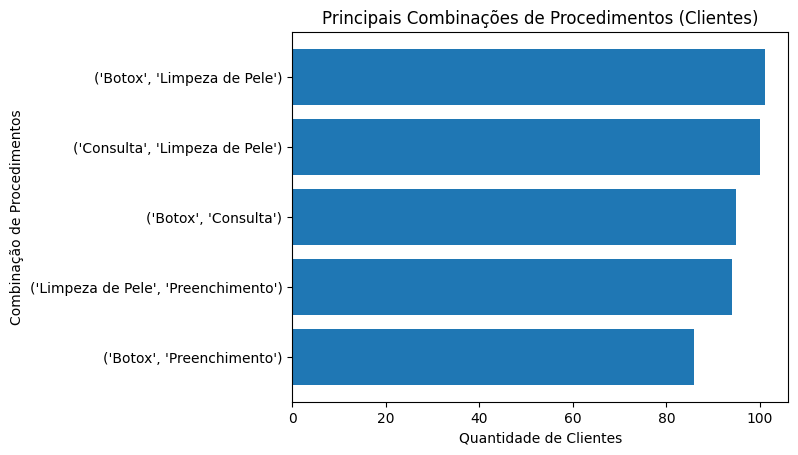

In [82]:
import matplotlib.pyplot as plt
import os


# pegar top 5
top5 = df_combinacoes.head(5).copy()

# transformar nomes em string
top5['combinacao_str'] = top5['combinacao'].astype(str)

plt.figure()

plt.barh(top5['combinacao_str'], top5['quantidade'])

plt.xlabel('Quantidade de Clientes')
plt.ylabel('Combinação de Procedimentos')
plt.title('Principais Combinações de Procedimentos (Clientes)')

plt.gca().invert_yaxis()

plt.savefig(os.path.join(caminho, 'combinacoes_procedimentos.png'), bbox_inches='tight')

plt.show()

##  Conclusão — Clinic Revenue Intelligence

A análise dos dados revelou padrões claros sobre o comportamento dos clientes e a dinâmica de consumo dentro da clínica.

###  Principais Achados

* A **Limpeza de Pele** apresentou a maior taxa de retenção, indicando forte recorrência e baixo atrito para retorno.
* Além disso, foi o procedimento com maior presença nas combinações entre serviços, conectando-se diretamente com **Botox**, **Consulta** e **Preenchimento**.
* As combinações mais frequentes mostram que os clientes não consomem apenas um serviço isolado, mas transitam entre diferentes procedimentos ao longo do tempo.

###  Interpretação de Negócio

Os dados indicam que a **Limpeza de Pele funciona como um HUB de relacionamento com o cliente**, desempenhando um papel estratégico muito além do seu ticket médio.

Ela atua como:

* Porta de entrada para novos clientes
* Mecanismo de retenção (alta recorrência)
* Ponte para procedimentos de maior valor agregado

Por outro lado, procedimentos como **Botox** e **Preenchimento** aparecem como principais vetores de monetização, estando fortemente associados à base de clientes recorrentes.

###  Dinâmica do Modelo de Receita

A clínica apresenta uma estrutura clara de geração de valor:

* **Entrada:** Limpeza de Pele e Consulta
* **Relacionamento:** recorrência via serviços acessíveis
* **Monetização:** migração para procedimentos de maior ticket

###  Implicações Estratégicas

* Investir na atração de clientes via Limpeza de Pele pode gerar crescimento sustentável
* Estratégias comerciais podem explorar combinações naturais de serviços
* Existe potencial para criação de jornadas estruturadas (ex: limpeza → avaliação → procedimento estético)

---

###  Finalização

A análise demonstra que o crescimento da clínica não depende apenas de procedimentos de alto valor, mas da **capacidade de atrair, reter e desenvolver o relacionamento com o cliente ao longo do tempo**.

A Limpeza de Pele se consolida como o principal motor desse processo, conectando aquisição, retenção e monetização em um único fluxo.

---
